# 00｜一键体验：让网络记住一个秘密符号

这一页先不推导公式。运行后观察：序列开头是什么、模型最后回答什么，以及训练过程中 Accuracy 怎样变化。

**操作：**选择课程 Python 内核并点击 `Run All`。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from rnn_lab import (
    ExperimentConfig, predict_proba, run_experiment,
    plot_confusion_matrix, plot_sequence_sample, plot_training_history,
)

## 问题：隔了很久，还能记住第一条信息吗？

每条数据都是一段序列：

```text
秘密颜色 → 与答案无关的噪声 → …… → 查询标记
```

模型只有在最后看到查询标记时才回答。下面先用 LSTM 完成一次三分类任务。

**运行前先猜：**三类平衡时，随机猜测的 Accuracy 大约是 33.3%。模型需要明显超过这个水平，才说明学到了一些规律。

In [2]:
# ===== 第一轮只需要认识下面几个参数 =====
DEVICE = "cpu"
# 使用第 x 块 GPU 时改为 DEVICE = "cuda:x"，并把 x 换成课堂指定编号。

config = ExperimentConfig(
    cell_type="lstm",       # 循环单元：先使用 LSTM
    sequence_length=12,     # 一条序列包含 12 个时间步
    hidden_size=24,         # 隐藏状态维度
    epochs=30,              # 完整查看训练数据的次数
    train_size=900,
    val_size=240,
    test_size=240,
    batch_size=64,
    learning_rate=0.003,
    seed=42,
    device=DEVICE,
)

result = run_experiment(config)
print(f"模型：{config.cell_type.upper()}｜序列长度：{config.sequence_length}")
print(f"测试准确率：{result['metrics']['accuracy']:.1%}")
print(f"参数量：{result['parameter_count']:,}")
print(f"训练时间：{result['elapsed_seconds']:.2f} 秒")

模型：LSTM｜序列长度：12
测试准确率：100.0%
参数量：3,147
训练时间：0.63 秒


## 把输入、训练和预测都画出来

第一张图展示一条序列；第二张图展示训练过程；第三张图展示模型把三种真实秘密分别预测成了什么。

真实秘密： 蓝色
模型回答： 蓝色
三个类别的概率： [0.0, 0.0010000000474974513, 0.9990000128746033]


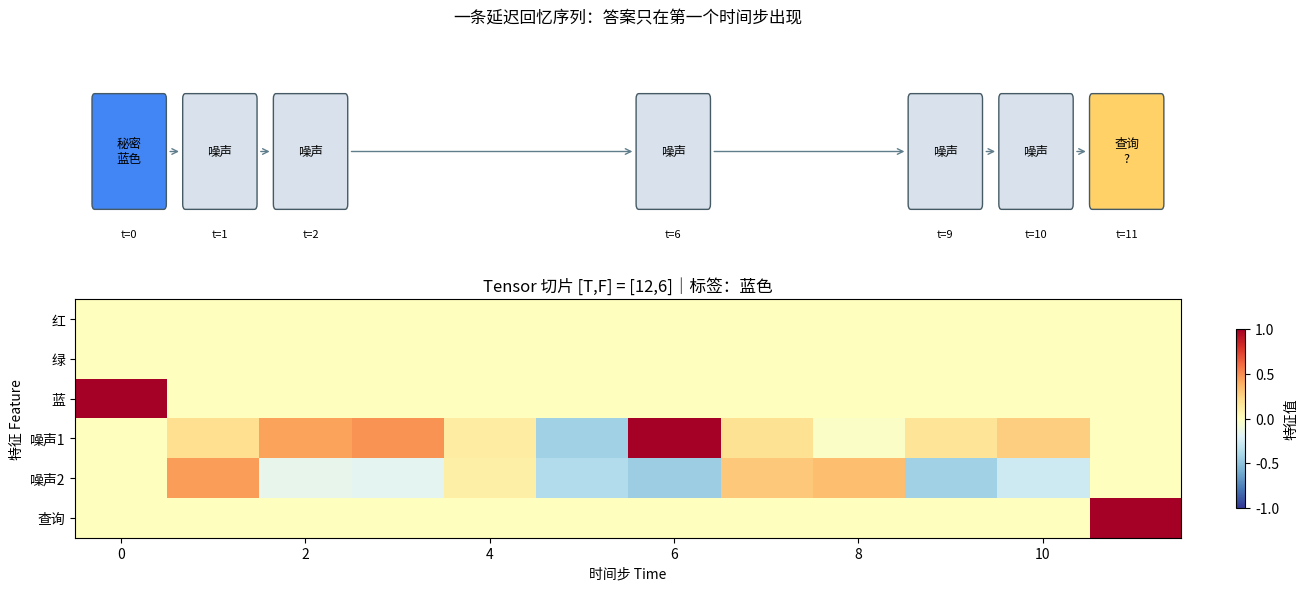

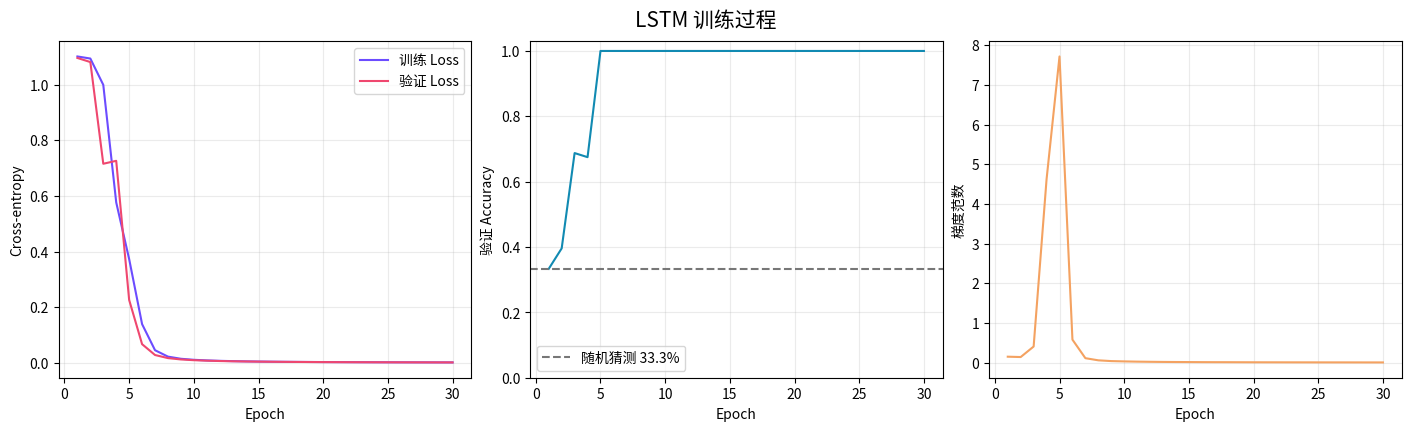

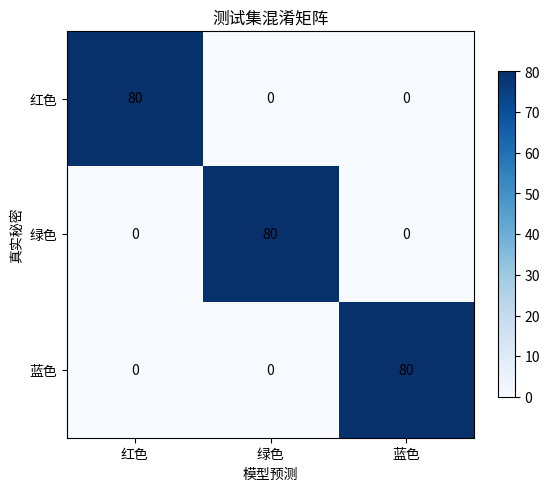

In [3]:
test_x, test_y = next(iter(result["loaders"]["test"]))

plot_sequence_sample(test_x, test_y, index=0)
plot_training_history(result["history"], title="LSTM 训练过程")
plot_confusion_matrix(
    result["metrics"]["targets"], result["metrics"]["predictions"],
    title="测试集混淆矩阵",
)

probabilities = predict_proba(result["model"], test_x[:1], device=DEVICE)[0]
predicted = int(probabilities.argmax())
names = ["红色", "绿色", "蓝色"]
print("真实秘密：", names[int(test_y[0])])
print("模型回答：", names[predicted])
print("三个类别的概率：", probabilities.numpy().round(3).tolist())

## 看图顺序

1. 秘密符号只在哪个时间步出现？
2. 中间噪声是否透露了标签？
3. Loss 是否总体下降，验证 Accuracy 是否总体上升？
4. 混淆矩阵是否主要集中在对角线？

这次结果只对应当前数据、随机种子和参数，不能直接推出某种循环单元永远更好。

## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)